In [21]:
# % pip install medmnist
# to download the dataset for the medmnist package

In [1]:
import torch 
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn 
import torchvision.models as models
from medmnist.dataset import PathMNIST
from medmnist import INFO
from torch.utils.data import DataLoader

from torchvision import transforms

d:\Develop\Andaconda\envs\pytorch_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw_transform = transforms.Compose([
    # transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_dataset = PathMNIST(split='train', transform=raw_transform, download=True)
val_dataset = PathMNIST(split='val', transform=raw_transform, download=True)
test_dataset = PathMNIST(split='test', transform=raw_transform, download=True)

data_flag = 'pathmnist'
info = INFO[data_flag]

Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz


### EDA

In [12]:
print("Dataset name:", data_flag)
print("Task:", info['task'])
print("Number of channels:", info['n_channels'])
print("Number of classes:", len(info['label']))
print("Labels:", info['label'])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Dataset name: pathmnist
Task: multi-class
Number of channels: 3
Number of classes: 9
Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Train size: 89996
Validation size: 10004
Test size: 7180


In [13]:
img, label = train_dataset[0]

print("Image shape:", img.shape)   # [C, H, W]
print("Label:", label)
print("Image min:", img.min().item())
print("Image max:", img.max().item())

Image shape: torch.Size([3, 28, 28])
Label: [0]
Image min: 0.6431372761726379
Image max: 0.8941176533699036


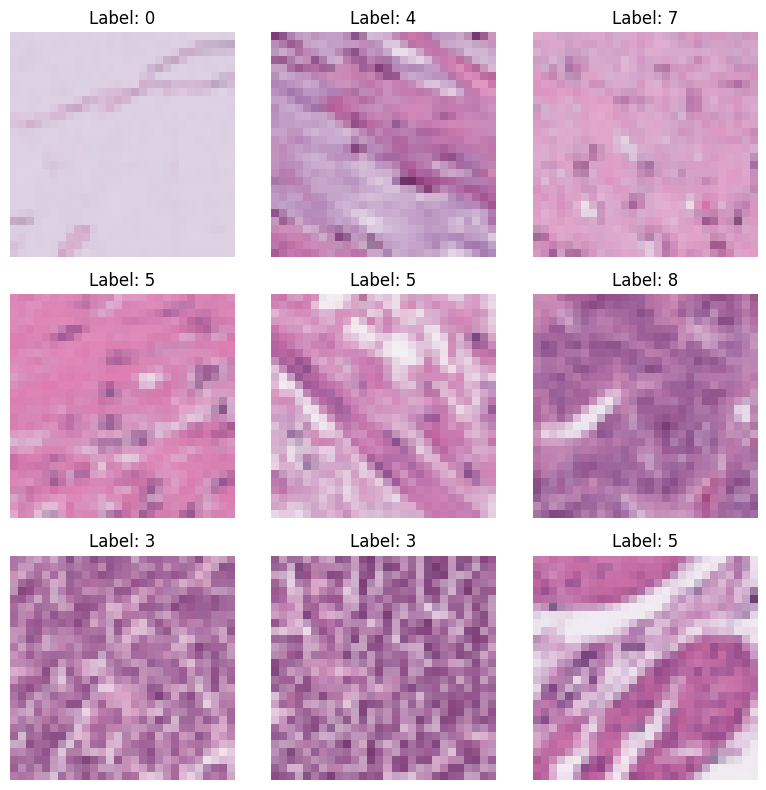

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    
    # PathMNIST usually has 3 channels, so transpose to HWC
    img_np = img.permute(1, 2, 0).numpy()
    
    ax.imshow(img_np)
    ax.set_title(f"Label: {label.item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Preprocessing

In [9]:
# # Normalized the pixel range from 0~1 to -1~1
sd_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5,0.5,0.5),
        std=(0.5,0.5,0.5)
    )
])

# In order to match the normalization with the perTrained Model, we need to transform the dataset with the same image normalization
pretrainVGG_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    ) # The normalization for the ImageNet
])



# train_dataset = PathMNIST(split='train', transform=pretrainVGG_transform, download=True)
# val_dataset = PathMNIST(split='val', transform=pretrainVGG_transform, download=True)
# test_dataset = PathMNIST(split='test', transform=pretrainVGG_transform, download=True)
# train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True) 
# val_dataloader = DataLoader(val_dataset, batch_size = 128, shuffle=True)

# Architecture Building 

In [3]:
class pretrainVGG16(nn.Module):
    def __init__(self, num_classes=9):
        # Override 
        super(pretrainVGG16, self).__init__()
        
        # Load the pretrained VGG16
        self.vgg16 = models.vgg16(pretrained=True)

        # Freeze the layers of VGG16
        for para in self.vgg16.parameters():
            para.requires_grad = False

        # Replace the last fully connected layer with a new one
        # Make it fits the number of PM classes 
        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(
            in_features=in_features,
            out_features=num_classes
        ) 

    def forward(self, x):
        output = self.vgg16(x)
        return output
    
class VGG16(nn.Module):
    def __init__(self, num_classes=9):
        # Override 
        super(VGG16, self).__init__()

        # VGG16 convolution blocks
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4
            # nn.Conv2d(256, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.MaxPool2d(2, 2),

            # Block 5
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.MaxPool2d(2, 2),
        )

        # classifier
        self.classifier = nn.Sequential(
            nn.Linear(256*28*28, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        output = self.classifier(x)
        return output




In [4]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=9):
        super(ResNet18, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers 
        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1) 
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2) 
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)  
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2) 

        # Classifier head (MLP) 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [BasicBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


class BasicBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,
                                kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                                kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)
    
class pretrainResNet18(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()

        self.resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        for param in self.resnet18.parameters():
            param.requires_grad = False

        self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet18(x)

In [7]:

# # model Check
# model = pretrainVGG16()
# x = x.unsqueeze(0)
# out = model(x)
# print(out)

# model = VGG16()
# out = model(x)
# print(out)

# model = ResNet18()
# out = model(x)
# print(out)

# model = pretrainResNet18()
# out = model(x)
# print(out)

# Training and Hyper-parameter tuning 

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from dataclasses import dataclass, field
from torchvision import transforms
from typing import List, Type
import time
import os
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from typing import Optional, Callable


@dataclass
class TrainConfig: 
    # Training process configs
    epochs: int = 10
    lr: float = 1e-4
    optimizer_cls: Type[torch.optim.Optimizer] = torch.optim.Adam
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    batch_size: int = 128

    # Validation configs
    early_stopping_patience: int = 3
    early_stopping_metric: str = "accuracy" # Cant use Loss

    # Data transformer
    transform: Optional[Callable] = None

    # Checkpoint configs
    save_checkpoints: bool = False 
    checkpoints_dir: dir = "checkpoints"
    save_frequency: int = 2
    save_best_only: bool = True


@dataclass
class TrainHistoryRecords: 
    epochs: List[float] = field(default_factory=list)
    train_losses: List[float] = field(default_factory=list)
    train_accuracies: List[float] = field(default_factory=list)
    valid_losses: List[float] = field(default_factory=list)
    valid_accuracies: List[float] = field(default_factory=list)


def plot_training_history(history: TrainHistoryRecords, save: bool = False, save_path: str = None):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    axes[0].plot(history.epochs, history.train_losses, 
                 label='Train Loss', marker='o', linewidth=2)
    axes[0].plot(history.epochs, history.valid_losses, 
                 label='Valid Loss', marker='s', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Plot Accuracy
    axes[1].plot(history.epochs, history.train_accuracies, 
                 label='Train Accuracy', marker='o', linewidth=2)
    axes[1].plot(history.epochs, history.valid_accuracies, 
                 label='Valid Accuracy', marker='s', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # if save and save_path:

    #     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    #     print(f"Plot saved to: {save_path}")
    
    plt.show()

def save_history_to_csv(history: TrainHistoryRecords, 
                        config: TrainConfig, 
                        save_dir: str = "training_logs"):
    os.makedirs(save_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = (f"history_ep{config.epochs}_"
                f"bs{config.batch_size}_"
                f"lr{config.lr}_"
                f"{config.device}_"
                f"{timestamp}.csv")
    
    filepath = os.path.join(save_dir, filename)
    
    df = pd.DataFrame({
        'Epoch': history.epochs,
        'Train_Loss': history.train_losses,
        'Train_Accuracy': history.train_accuracies,
        'Valid_Loss': history.valid_losses,
        'Valid_Accuracy': history.valid_accuracies
    })
    
    df.to_csv(filepath, index=False)
    print(f"History saved to: {filepath}")
    
    return filepath

def evaluate(model, loader, loss_fn, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device).float()
            labels = labels.to(device).squeeze().long()

            outputs = model(images)

            loss = loss_fn(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()

            total += images.size(0)
    
    output_avg_loss = total_loss/total
    output_accuracy = correct/total 

    return output_avg_loss, output_accuracy

def train(
    model: nn.Module,
    config: TrainConfig,
    # train_loader: DataLoader,
    # valid_loader: DataLoader | None = None
    # train_dataset,
    # valid_dataset
    ):
    
    # Pre-set config session 
    device = torch.device(config.device)
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = config.optimizer_cls(model.parameters(),
                                     lr=config.lr)
    
    # Initalization Variables
    history = TrainHistoryRecords()
    best_metric = None
    early_stop_idx = 0

    # Dataset Set UP
    train_dataset = PathMNIST(split='train', transform=config.transform, download=True)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    valid_dataset = PathMNIST(split='val', transform=config.transform, download=True)
    valid_loader = DataLoader(valid_dataset, batch_size=config.batch_size, shuffle=True)

    print("+"*41)
    print(f"Training starts on: {device}")
    print("+"*41)
    

    for epoch in range(1, config.epochs + 1):
        model.train()
 
        total_loss = 0.0
        correct = 0
        total = 0
        batch_idx = 0
        start = time.time()

        for images, labels in train_loader:
            images = images.to(device).float()
            labels = labels.to(device).squeeze().long()
 
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
 
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            batch_correct = (preds == labels).sum().item()
            correct += batch_correct
            total += images.size(0)
            # if batch_idx % 50 == 0:
            #     print(f"Batch {batch_idx} ||  Current Batah Loss: {loss.item():<.4} || Current Batah Accuracy: {batch_correct/images.size(0):<.4} || Current Total AvgLoss: {total_loss/total:<.4} || Accuracy: {correct/total:<.4}, ")
            batch_idx += 1
 
        avg_loss = total_loss / total
        accuracy = correct / total
        elpased = time.time() - start
 
        history.epochs.append(epoch)
        history.train_losses.append(avg_loss)
        history.train_accuracies.append(accuracy)
 

        val_loss, val_acc = evaluate(
            model,
            valid_loader,
            loss_fn,
            device
        )

        history.valid_losses.append(val_loss)
        history.valid_accuracies.append(val_acc)

        print(
            f"Epoch: {epoch:<8}\n Train Average Loss: {avg_loss:<12.4f} ||Train Accuracy: {accuracy:<12.4f} || Train Time Spent: {elpased:<.4}\n Validation Average Loss: {val_loss:.4f} ||Validation Accuracy: {val_acc:.4f}")

        metric = val_acc if config.early_stopping_metric == "accuracy" else -val_loss

        ### EarlyStop Logics
        if best_metric is None or metric > best_metric:

            best_metric = metric
            early_stop_idx = 0

        else:

            early_stop_idx += 1


        if config.save_checkpoints:
            os.makedirs(config.checkpoints_dir,
                        exist_ok=True)
            
            is_best = accuracy >= max(history.valid_accuracies)
            save_this_epoch = (
                config.save_frequency is not None 
                and
                epoch % config.save_frequency == 0
            )

            if is_best or save_this_epoch:
                checkpoint = {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "config": config,
                    "history": history
                }

                if is_best and config.save_best_only:
                    ckpt_path = os.path.join(config.checkpoints_dir, "best.pt")
                    torch.save(checkpoint, ckpt_path)
                    print(f"Best checkpoint saved (accuracy={accuracy:.4f}), saveing path is: {ckpt_path}")

                if save_this_epoch:
                    ckpt_path = os.path.join(config.checkpoints_dir, f"epoch_{epoch:03d}.pt")
                    torch.save(checkpoint, ckpt_path)
                    print(f"Epoch checkpoint saved, saveing path is: {ckpt_path}")

            if early_stop_idx >= config.early_stopping_patience:
                print("\nEarly stopping triggered")
                break        
        
    print("="*41)
    print("Training Completed!")

    plot_training_history(
        history=history,
        save=False # Change to True if you want to save the image
    )

    csv_path  = save_history_to_csv(
        history=history,
        config=config,
        model_name=config.checkpoints_dir,
        save_dir="meta_logs"
    )
    return history, csv_path




Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz
+++++++++++++++++++++++++++++++++++++++++
Training starts on: cuda
+++++++++++++++++++++++++++++++++++++++++
Epoch: 1       
 Train Average Loss: 0.6806       ||                  Train Accuracy: 0.7566       || Train Time Spent:                     214.8
 Validation Average Loss: 0.5000 ||                          Validation Accuracy: 0.8237
Epoch: 2       
 Train Average Loss: 0.6048       ||                  Train Accuracy: 0.7807       || Train Time Spent:                     217.3
 Validation Average Loss: 0.4808 ||                          Validation Accuracy: 0.8292
Epoch checkpoint saved, saveing path is: VGG_pretrain\epoch_002.pt
Training Completed!


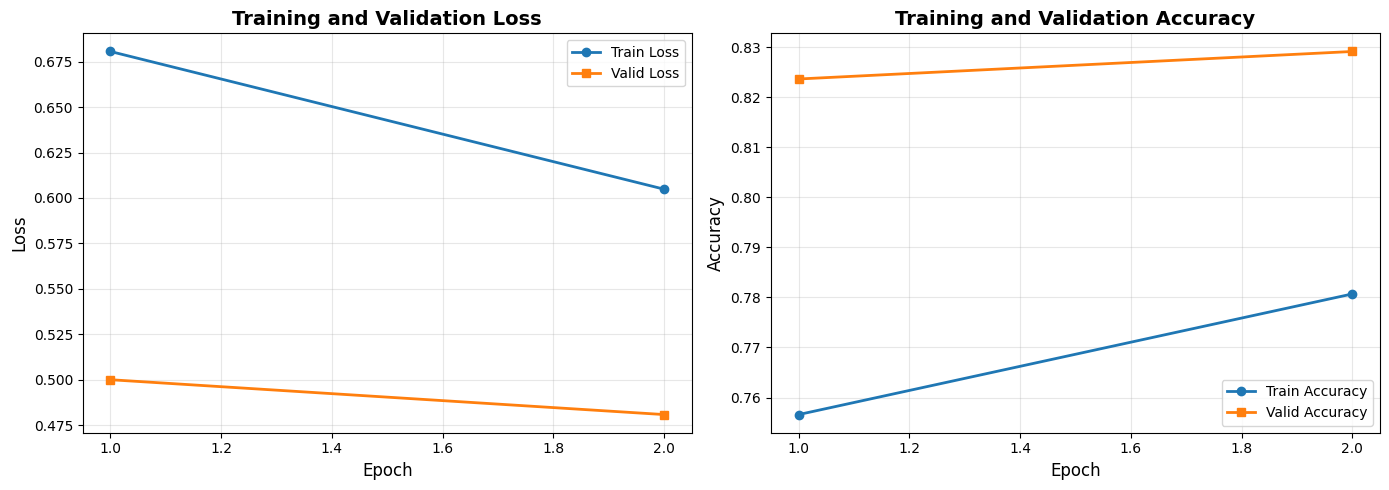

TypeError: save_history_to_csv() got an unexpected keyword argument 'model_name'

In [12]:
model = pretrainVGG16()
config = TrainConfig(
    epochs=2,
    lr=1e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=True,
    checkpoints_dir="VGG_pretrain",
    transform = pretrainVGG_transform,
    save_best_only=True
)
history = train(model = model,
                config = config)

In [ ]:
model = ResNet18()
config = TrainConfig(
    epochs=10,
    lr=1e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False,
    checkpoints_dir="ResNet18",
    save_best_only=True,
    early_stopping_metric="accuracy"
)
history = train(model = model,
                train_loader = train_dataloader,
                valid_loader = val_dataloader,
                config = config)

+++++++++++++++++++++++++++++++++++++++++
Training starts on: cuda
+++++++++++++++++++++++++++++++++++++++++
Epoch: 1        || Train Average Loss: 0.6443       || Train Accuracy: 0.7684       || Train Time Spent: 151.8
Validation Average Loss: 0.6148 || Validation Accuracy: 0.7774
Epoch: 2        || Train Average Loss: 0.3196       || Train Accuracy: 0.8864       || Train Time Spent: 148.6
Validation Average Loss: 0.5889 || Validation Accuracy: 0.7892
Epoch: 3        || Train Average Loss: 0.2216       || Train Accuracy: 0.9221       || Train Time Spent: 146.5
Validation Average Loss: 0.6277 || Validation Accuracy: 0.7782
Epoch: 4        || Train Average Loss: 0.1654       || Train Accuracy: 0.9419       || Train Time Spent: 146.4
Validation Average Loss: 0.2818 || Validation Accuracy: 0.9092
Epoch: 5        || Train Average Loss: 0.1337       || Train Accuracy: 0.9535       || Train Time Spent: 146.0
Validation Average Loss: 0.3579 || Validation Accuracy: 0.8792
Epoch: 6        || Tr

In [ ]:
model = pretrainResNet18()
config = TrainConfig(
    epochs=10,
    lr=1e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False,
    checkpoints_dir="preTrainResNet18",
    save_best_only=True,
    early_stopping_metric="accuracy",
    transform = sd_transform
)
history = train(model = model,
                # train_loader = train_dataloader,
                # valid_loader = val_dataloader,
                config = config)

+++++++++++++++++++++++++++++++++++++++++
Training starts on: cuda
+++++++++++++++++++++++++++++++++++++++++
Epoch: 1        || Train Average Loss: 0.5362       || Train Accuracy: 0.8302       || Train Time Spent: 96.36
Validation Average Loss: 0.3568 || Validation Accuracy: 0.8796
Epoch: 2        || Train Average Loss: 0.3553       || Train Accuracy: 0.8774       || Train Time Spent: 111.7
Validation Average Loss: 0.3357 || Validation Accuracy: 0.8841
Epoch: 3        || Train Average Loss: 0.3303       || Train Accuracy: 0.8858       || Train Time Spent: 96.06
Validation Average Loss: 0.3007 || Validation Accuracy: 0.8961
Epoch: 4        || Train Average Loss: 0.3163       || Train Accuracy: 0.8883       || Train Time Spent: 105.3
Validation Average Loss: 0.2907 || Validation Accuracy: 0.9001
Epoch: 5        || Train Average Loss: 0.3097       || Train Accuracy: 0.8905       || Train Time Spent: 97.97
Validation Average Loss: 0.2875 || Validation Accuracy: 0.9023
Epoch: 6        || Tr

In [30]:
model = pretrainResNet18()
config = TrainConfig(
    epochs=10,
    lr=3e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False,
    checkpoints_dir="preTrainResNet18",
    save_best_only=True,
    early_stopping_metric="accuracy"
)
history = train(model = model,
                train_loader = train_dataloader,
                valid_loader = val_dataloader,
                config = config)

+++++++++++++++++++++++++++++++++++++++++
Training starts on: cuda
+++++++++++++++++++++++++++++++++++++++++
Epoch: 1        || Train Average Loss: 0.4468       || Train Accuracy: 0.8476       || Train Time Spent: 240.4
Validation Average Loss: 0.3180 || Validation Accuracy: 0.8880
Epoch: 2        || Train Average Loss: 0.3384       || Train Accuracy: 0.8801       || Train Time Spent: 219.5
Validation Average Loss: 0.3568 || Validation Accuracy: 0.8696
Epoch: 3        || Train Average Loss: 0.3263       || Train Accuracy: 0.8842       || Train Time Spent: 173.7
Validation Average Loss: 0.3039 || Validation Accuracy: 0.8935
Epoch: 4        || Train Average Loss: 0.3160       || Train Accuracy: 0.8869       || Train Time Spent: 194.9
Validation Average Loss: 0.3081 || Validation Accuracy: 0.8908
Epoch: 5        || Train Average Loss: 0.3112       || Train Accuracy: 0.8888       || Train Time Spent: 214.4
Validation Average Loss: 0.2852 || Validation Accuracy: 0.9006
Epoch: 6        || Tr

In [ ]:
model = pretrainResNet18()
config = TrainConfig(
    epochs=10,
    lr=3e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False,
    checkpoints_dir="preTrainResNet18",
    save_best_only=True,
    early_stopping_metric="accuracy"
)
history = train(model = model,
                train_loader = train_dataloader,
                valid_loader = val_dataloader,
                config = config)

In [ ]:
####
# DropOut
# Learning Rate
# Optimizer
# Epoch


In [ ]:
# Trunck to empty the gpu cache
import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# Evaluation with Validation

# Performace Metrics